# Extension: Does the relation hold after 1984?

The original paper ends in 1984. This notebook repeats the main analysis for 1985–2020 and compares the two periods.


## 1. Why this extension?

There are many years of additional market data after the original study. I use them to ask a simple question:

**Does the relationship between volatility and returns look similar after 1984?**

This is an exploratory extension, not a new model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import skew as sk_skew
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9, 4)

DATA_DIR = "data"
daily = pd.read_csv(f"{DATA_DIR}/ff_daily.csv", parse_dates=["date"], index_col="date") / 100.0
monthly = pd.read_csv(f"{DATA_DIR}/ff_monthly.csv", parse_dates=["date"], index_col="date") / 100.0
print("Daily  :", daily.index.min().date(), "-", daily.index.max().date())
print("Monthly:", monthly.index.min().date(), "-", monthly.index.max().date())

Daily  : 1926-11-03 - 2020-12-31
Monthly: 1927-01-01 - 2020-12-01


In [2]:
# same helper functions as notebook 1, copied here so this notebook runs standalone

def monthly_sigma(daily_df, start, end, col="Mkt"):
    d = daily_df.loc[start:end, [col]].copy()
    d["ym"] = d.index.to_period("M")

    def _sigma(r):
        r = r.values
        if len(r) < 2:
            return np.nan
        s2 = np.sum(r**2) + 2 * np.sum(r[:-1] * r[1:])
        if s2 <= 0:
            s2 = np.sum(r**2)  # fallback, see section 2 below
        return np.sqrt(s2)

    s = d.groupby("ym")[col].apply(_sigma)
    s.index = s.index.to_timestamp()
    s.name = "sigma"
    return s


def arima_decompose(sigma):
    ln_sigma = np.log(sigma)
    fit = ARIMA(ln_sigma, order=(0, 1, 3), trend="t").fit()
    fitted_ln = fit.fittedvalues.copy()
    fitted_ln.iloc[0] = np.nan
    V = fit.resid.var()
    sigma_hat = np.exp(fitted_ln + 0.5 * V)
    sigma2_hat = np.exp(2 * fitted_ln + 2 * V)
    return fit, sigma_hat, sigma2_hat


def build_frame(start, end):
    sigma = monthly_sigma(daily, start, end)
    fit, sigma_hat, sigma2_hat = arima_decompose(sigma)
    ex = (monthly["Mkt"] - monthly["RF"]).loc[start:end]
    df = pd.DataFrame({"ex": ex, "sigma": sigma, "sigma_hat": sigma_hat,
                        "sigma2": sigma ** 2, "sigma2_hat": sigma2_hat}).dropna()
    df["sigma_u"] = df["sigma"] - df["sigma_hat"]
    df["sigma2_u"] = df["sigma2"] - df["sigma2_hat"]
    return df, fit


def fit_eq6_eq7(df, xcol, xucol):
    w = 1.0 / df[xcol] ** 2
    X6 = sm.add_constant(df[[xcol]])
    m6 = sm.WLS(df["ex"], X6, weights=w).fit(cov_type="HC0")
    X7 = sm.add_constant(df[[xcol, xucol]])
    m7 = sm.WLS(df["ex"], X7, weights=w).fit(cov_type="HC0")
    return m6, m7


ORIGINAL = ("1928-01-01", "1984-12-31")
EXTENSION = ("1985-01-01", "2020-12-31")

## 2. A problem with the volatility measure

The paper's volatility formula can theoretically produce a negative value because of the autocovariance correction.

This occurs in March 2020 in this dataset. For that month, I use the sum of squared returns as a simple fallback so that the volatility calculation can continue.

This is a limitation of the extension and is documented rather than hidden.


In [3]:
d = daily.loc["2020-03-01":"2020-03-31", "Mkt"]
naive_var = np.sum(d.values**2)
corrected_var = np.sum(d.values**2) + 2*np.sum(d.values[:-1]*d.values[1:])
print(f"March 2020: {len(d)} trading days, daily return range [{d.min():.1%}, {d.max():.1%}]")
print(f"eq.(2) with autocovariance correction: {corrected_var:.5f}  (negative -> estimator undefined)")
print(f"fallback, sum of squares only:         {naive_var:.5f}  ->  sigma = {np.sqrt(naive_var):.4f} "
      f"({np.sqrt(naive_var)*np.sqrt(12):.1%} annualized)")

March 2020: 22 trading days, daily return range [-12.0%, 9.3%]
eq.(2) with autocovariance correction: -0.00186  (negative -> estimator undefined)
fallback, sum of squares only:         0.07226  ->  sigma = 0.2688 (93.1% annualized)


## 3. Results for 1985–2020

I now run the same basic calculations for the original period and the extension period.


In [4]:
df_orig, arima_orig = build_frame(*ORIGINAL)
df_ext, arima_ext = build_frame(*EXTENSION)

summary_rows = []
for label, df in [("1928-1984 (original)", df_orig), ("1985-2020 (extension)", df_ext)]:
    summary_rows.append({
        "Period": label, "N": len(df),
        "Mean sigma_mt": df["sigma"].mean(), "Std sigma_mt": df["sigma"].std(ddof=1),
        "Mean excess return": df["ex"].mean(), "Std excess return": df["ex"].std(ddof=1),
    })
pd.DataFrame(summary_rows).set_index("Period").round(4)

,N,Mean sigma_mt,Std sigma_mt,Mean excess return,Std excess return
Period,,,,,
1928-1984 (original),683,0.0458,0.0315,0.0060,0.0588
1985-2020 (extension),431,0.0432,0.0277,0.0074,0.0449


In [5]:
def fmt(coef, se):
    return f"{coef:.4f} ({se:.4f})"

comparison_rows = []
for label, df in [("1928-1984 (original)", df_orig), ("1985-2020 (extension)", df_ext)]:
    for p, xcol, xucol in [(1, "sigma_hat", "sigma_u"), (2, "sigma2_hat", "sigma2_u")]:
        m6, m7 = fit_eq6_eq7(df, xcol, xucol)
        comparison_rows.append({
            "Period": label, "p": p,
            "beta, eq.6 (predictable vol only)": fmt(m6.params[xcol], m6.bse[xcol]),
            "beta, eq.7": fmt(m7.params[xcol], m7.bse[xcol]),
            "gamma, eq.7 (unpredicted vol)": fmt(m7.params[xucol], m7.bse[xucol]),
            "R2, eq.7": round(m7.rsquared, 3),
        })

comp_tab = pd.DataFrame(comparison_rows).set_index(["Period", "p"])
comp_tab

beta, eq.6 (predictable vol only)        beta, eq.7  \
Period                p                                                       
1928-1984 (original)  1                   0.0361 (0.1172)  -0.0552 (0.1126)   
                      2                   0.8513 (1.6761)   0.6832 (1.5266)   
1985-2020 (extension) 1                  -0.0347 (0.1620)  -0.1596 (0.1445)   
                      2                  -1.7606 (2.3804)  -1.9137 (2.1814)   

                        gamma, eq.7 (unpredicted vol)  R2, eq.7  
Period                p                                          
1928-1984 (original)  1              -1.0492 (0.1186)     0.165  
                      2              -5.5855 (1.9219)     0.128  
1985-2020 (extension) 1              -0.9187 (0.0948)     0.225  
                      2              -4.8925 (1.1470)     0.164

**Reading the results.** The coefficients can be compared across the two periods, but they should not be treated as exact estimates of a structural relationship. The sample, data source, and market conditions differ.


## 4. Comparing the two periods

I add an interaction between the volatility measures and a post-1984 dummy. This gives a simple test of whether the estimated coefficients differ between the two periods.


In [6]:
d1 = df_orig[["ex", "sigma_hat", "sigma_u"]].copy(); d1["post1984"] = 0
d2 = df_ext[["ex", "sigma_hat", "sigma_u"]].copy();  d2["post1984"] = 1
pooled = pd.concat([d1, d2])
pooled["sigma_hat_x_post"] = pooled["sigma_hat"] * pooled["post1984"]
pooled["sigma_u_x_post"] = pooled["sigma_u"] * pooled["post1984"]

X = sm.add_constant(pooled[["sigma_hat", "sigma_u", "post1984", "sigma_hat_x_post", "sigma_u_x_post"]])
w = 1.0 / pooled["sigma_hat"] ** 2
pooled_model = sm.WLS(pooled["ex"], X, weights=w).fit(cov_type="HC0")
pooled_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                     ex   R-squared:                       0.185
Model:                            WLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     35.89
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.03e-34
Time:                        20:12:05   Log-Likelihood:                 1976.3
No. Observations:                1114   AIC:                            -3941.
Df Residuals:                    1108   BIC:                            -3910.
Df Model:                           5                                         
Covariance Type:                  HC0                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0076      0.004      1.912      0.056      -0.000       0.015
sigma_hat           -0.0552      0.113     -0.490      0.624      -0.276       0.166
sigma_u             -1.0492      0.119     -8.847      0.000      -1.282      -0.817
post1984             0.0059      0.007      0.863      0.388      -0.007       0.019
sigma_hat_x_post    -0.1044      0.183     -0.570      0.569      -0.463       0.255
sigma_u_x_post       0.1305      0.152      0.859      0.390      -0.167       0.428
==============================================================================
Omnibus:                       36.361   Durbin-Watson:                   2.118
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.522
Skew:                           0.353   Prob(JB):                     7.91e-11
Kurtosis:                       3.711   Cond. No.                         202.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC0)
"""

**Interpretation.** The interaction terms are not statistically significant in this sample. This means the data do not provide strong evidence that the estimated coefficients changed after 1984.


## 5. Rolling-window check

I also estimate the regression over rolling 15-year windows. This is just a visual check of how the coefficients move over time.


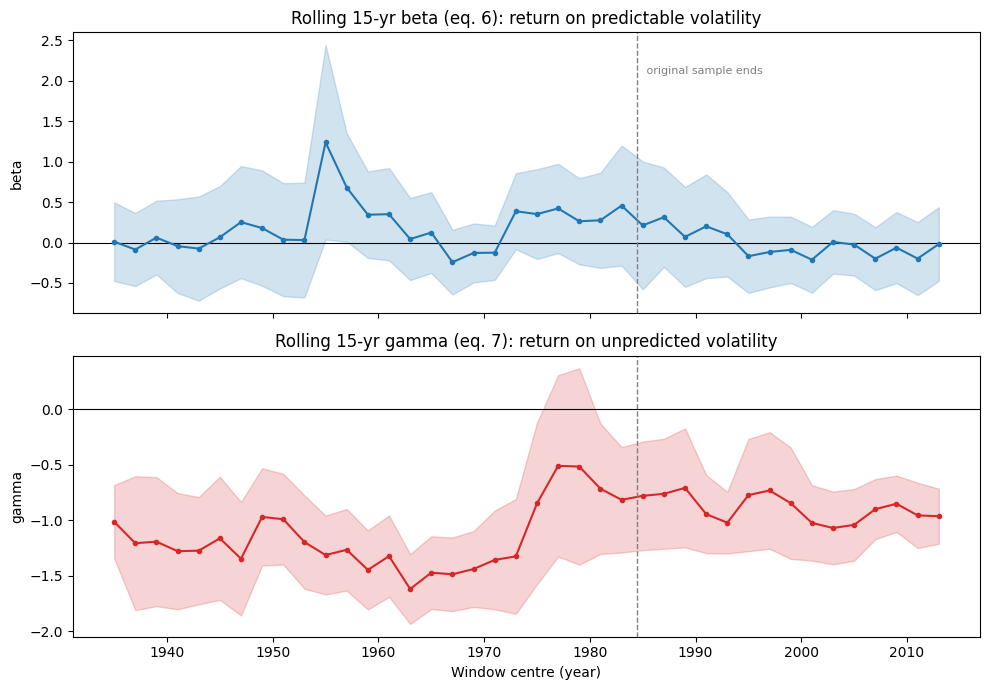

gamma: 100% of rolling windows negative; 95% reliably negative (95% CI excludes 0)
beta:  62% of rolling windows positive; 5% statistically distinguishable from 0


In [7]:
WINDOW_YEARS, STEP_YEARS = 15, 2
records = []
for y0 in range(1928, 2021 - WINDOW_YEARS + 1, STEP_YEARS):
    y1 = y0 + WINDOW_YEARS - 1
    s, e = f"{y0}-01-01", f"{y1}-12-31"
    try:
        df_w, _ = build_frame(s, e)
        if len(df_w) < 60:
            continue
        m6, m7 = fit_eq6_eq7(df_w, "sigma_hat", "sigma_u")
        records.append({
            "mid_year": (y0 + y1) / 2,
            "beta": m6.params["sigma_hat"], "beta_se": m6.bse["sigma_hat"],
            "gamma": m7.params["sigma_u"], "gamma_se": m7.bse["sigma_u"],
        })
    except Exception:
        pass

roll = pd.DataFrame(records)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].axhline(0, color="black", lw=0.8)
axes[0].plot(roll["mid_year"], roll["beta"], color="tab:blue", marker="o", ms=3)
axes[0].fill_between(roll["mid_year"], roll["beta"] - 1.96*roll["beta_se"],
                      roll["beta"] + 1.96*roll["beta_se"], alpha=0.2, color="tab:blue")
axes[0].set_title("Rolling 15-yr beta (eq. 6): return on predictable volatility")
axes[0].set_ylabel("beta")

axes[1].axhline(0, color="black", lw=0.8)
axes[1].plot(roll["mid_year"], roll["gamma"], color="tab:red", marker="o", ms=3)
axes[1].fill_between(roll["mid_year"], roll["gamma"] - 1.96*roll["gamma_se"],
                      roll["gamma"] + 1.96*roll["gamma_se"], alpha=0.2, color="tab:red")
axes[1].set_title("Rolling 15-yr gamma (eq. 7): return on unpredicted volatility")
axes[1].set_ylabel("gamma")
axes[1].set_xlabel("Window centre (year)")
axes[1].axvline(1984.5, color="gray", ls="--", lw=1)
axes[0].axvline(1984.5, color="gray", ls="--", lw=1)
axes[0].text(1985, axes[0].get_ylim()[1]*0.8, " original sample ends", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

print(f"gamma: {(roll['gamma'] < 0).mean():.0%} of rolling windows negative; "
      f"{(roll['gamma'] + 1.96*roll['gamma_se'] < 0).mean():.0%} reliably negative (95% CI excludes 0)")
print(f"beta:  {(roll['beta'] > 0).mean():.0%} of rolling windows positive; "
      f"{(np.abs(roll['beta']) > 1.96*roll['beta_se']).mean():.0%} statistically distinguishable from 0")

**Reading the plot.** The coefficient on unpredictable volatility is usually negative, while the coefficient on predictable volatility is more variable. Because the windows overlap, this should be treated as descriptive evidence rather than a separate set of independent tests.


## 6. Leverage effect check

FSS discuss financial leverage as one possible explanation for the negative relationship. I repeat their basic leverage regression for both periods.


In [8]:
def leverage_test(start, end):
    sigma = monthly_sigma(daily, start, end)
    R = monthly["Mkt"].loc[start:end]
    d = pd.DataFrame({"sigma": sigma, "R": R}).dropna()
    d["dlnsigma"] = np.log(d["sigma"] / d["sigma"].shift(1))
    d["ln1R"] = np.log(1 + d["R"])
    d = d.dropna()
    X = sm.add_constant(d["ln1R"])
    return sm.OLS(d["dlnsigma"], X).fit(cov_type="HC0")

lev_rows = []
for label, (s, e) in [("1928-1984 (original)", ORIGINAL), ("1985-2020 (extension)", EXTENSION)]:
    m = leverage_test(s, e)
    lev_rows.append({"Period": label, "N": int(m.nobs),
                      "alpha1 (elasticity)": m.params["ln1R"], "se": m.bse["ln1R"],
                      "t": m.tvalues["ln1R"]})
pd.DataFrame(lev_rows).set_index("Period").round(3)

,N,alpha1 (elasticity),se,t
Period,,,,
1928-1984 (original),683,-1.907,0.365,-5.226
1985-2020 (extension),431,-3.017,0.586,-5.151


**Comparison with the paper.** The leverage coefficients are broadly consistent with the original result, although the exact values differ because the data are different.


## 7. Limitations

- Same market-proxy issue as notebook 1 (Fama/French `Mkt` instead of S&P 500/CRSP).
- A handful of extreme months (Oct 1987, 2008-09, Mar-Apr 2020) probably have outsized influence on the extension-period estimates - I didn't try winsorizing or trimming them.
- The 1984 break point is chosen because it's where the original sample ends, not because I tested for the best-fitting break date.
- The rolling windows overlap (15-year windows, 2-year steps), so nearby points on the plot aren't independent - read the figure qualitatively, not as a series of separate hypothesis tests.
- The eq. (2) negative-variance fix (Section 2) is just a quick patch for one month, not a general solution.
- Same GARCH simplifications as notebook 1 apply here too, though GARCH isn't actually used in this notebook.

## 8. Conclusion

The extension gives a similar broad pattern to the original study: the predictable-volatility coefficient is less stable, while the coefficient on unpredictable volatility is generally negative.

The result is interesting, but it should not be treated as proof that the original relationship is unchanged over time. The data and methodology have several limitations.
